# Finite Cyclic Period Finding

Find the period of a function on a known finite cyclic group by Fourier
sampling, then recover it using integer gcd computations.

[The problem](#problem) · [Quantum section](#quantum) ·
[Classical section](#classical) · [Success and cost](#cost)

The notebook includes an executable Qiskit implementation for small groups,
including group sizes that are not powers of two. Run the cells from top to
bottom. All circuits use a local ideal simulator.

<a id="problem"></a>
## 1. The problem

Let $N\geq2$ be known and let $\mathbb{Z}_N$ denote addition modulo $N$.
An oracle supplies a function $f:\mathbb{Z}_N\to\{0,1\}^m$ with the promise
that an unknown positive divisor $r$ of $N$ satisfies

$$
f(x)=f(x')\quad\Longleftrightarrow\quad x\equiv x'\pmod r.
$$

The goal is to find this least positive period $r$. The promise includes
distinct output values on different residue classes modulo $r$.
Periodicity alone, without this distinctness condition, would not suffice
for the argument below.

The hidden subgroup is

$$
K=\langle r\rangle
=\{0,r,2r,\ldots,N-r\}\leq\mathbb{Z}_N,
\qquad |K|=\frac{N}{r}.
$$

The function is constant on each coset of $K$ and separates different cosets.
There are $r$ cosets, so the output register needs $2^m\geq r$ possible labels.

| Period | Function | Hidden subgroup |
|---|---|---|
| $r=1$ | Constant | All of $\mathbb{Z}_N$ |
| $1<r<N$ | Repeated blocks with distinct labels within each block | A proper nontrivial subgroup |
| $r=N$ | One-to-one on $\mathbb{Z}_N$ | $\{0\}$ |

For $r=N$, the generator $N$ represents zero modulo $N$, and the period
reported by the algorithm is the positive integer $N$.

The finite cyclic formulation assumes $r\mid N$. An arbitrary finite window
of an integer-periodic function need not satisfy that assumption.
This distinction is explained in the
[finite and infinite period-finding sections of Childs and van Dam](https://arxiv.org/html/0812.0380v1).
The trivial group $\mathbb{Z}_1$ has period $1$ without any oracle queries.
The implementation below treats $N\geq2$.

<a id="quantum"></a>
## 2. Quantum section

### Prepare a uniform state and query the oracle

Represent each output as an $m$-bit label and use the XOR oracle

$$
U_f\lvert x\rangle\lvert z\rangle
=\lvert x\rangle\lvert z\oplus f(x)\rangle.
$$

Addition in the input group is modulo $N$. XOR is used only to make the
output operation reversible.

Prepare the uniform input state, then apply one oracle query:

$$
\frac{1}{\sqrt N}\sum_{x=0}^{N-1}\lvert x\rangle\lvert 0^m\rangle
\longmapsto
\frac{1}{\sqrt N}\sum_{x=0}^{N-1}\lvert x\rangle\lvert f(x)\rangle.
$$

To analyze the state, imagine measuring the output and obtaining $f(x_0)$,
with $0\leq x_0<r$. The promise leaves exactly the coset
$x_0+K$. Put $L=N/r$. Its normalized input state is

$$
\lvert x_0+K\rangle
=\frac{1}{\sqrt L}\sum_{a=0}^{L-1}\lvert x_0+ar\rangle.
$$

The circuit will leave the output unmeasured. Ignoring that register produces
the same input statistics as measuring it and discarding its value.

### Fourier sampling over the cyclic group

Use the positive-exponent Fourier transform

$$
F_N\lvert x\rangle
=\frac{1}{\sqrt N}\sum_{y=0}^{N-1}
e^{2\pi ixy/N}\lvert y\rangle.
$$

Its action on the coset state is

$$
F_N\lvert x_0+K\rangle
=\frac{1}{\sqrt{LN}}
\sum_{y=0}^{N-1}e^{2\pi ix_0y/N}
\left(\sum_{a=0}^{L-1}e^{2\pi iay/L}\right)\lvert y\rangle.
$$

The inner geometric sum is $L$ when $L\mid y$ and zero otherwise. Therefore

$$
F_N\lvert x_0+K\rangle
=\frac{1}{\sqrt r}\sum_{j=0}^{r-1}
e^{2\pi ix_0j/r}\lvert jN/r\rangle.
$$

Measuring the input gives a uniformly random multiple of $N/r$:

$$
Y=j\frac{N}{r},
\qquad j\ \text{uniform in }\{0,\ldots,r-1\}.
$$

Equivalently, the samples lie in

$$
K^\perp=\{y\in\mathbb{Z}_N:ry\equiv0\pmod N\}
=\left\{0,\frac Nr,\ldots,(r-1)\frac Nr\right\}.
$$

The unknown coset affects only phases, so every coset gives the same
measurement distribution. A single sample may contain only part of the
information needed to determine $r$. Zero is a valid outcome.

### Embed the exact transform in a qubit register

Use $n=\lceil\log_2N\rceil$ input qubits. When $N<2^n$, the states
$\lvert N\rangle,\ldots,\lvert 2^n-1\rangle$ do not represent group elements.
On the full qubit register, implement

$$
\widetilde F_N=F_N\oplus I_{2^n-N}.
$$

Applying $\widetilde F_N$ to $\lvert0^n\rangle$ prepares the required uniform
superposition over the first $N$ states. The transform preserves that
subspace, and the XOR oracle leaves the input label unchanged.

For $N=2^n$, the code uses Qiskit's
[QFTGate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.QFTGate).
It prepares the initial uniform state with Hadamard gates.

For other $N$, it constructs the block matrix above using
[UnitaryGate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.UnitaryGate).
This represents the mathematical transform to floating-point precision and
is suitable for small demonstrations. The dense matrix has $O(N^2)$ entries,
so this construction is not a scalable implementation in $\log N$.

Using an ordinary $n$-qubit QFT for such an $N$ would instead apply
$F_{2^n}$. That would change the sampled distribution. The demonstration
below uses $N=12$ to make the distinction concrete.

In [1]:
# Run this only if the dependencies are missing.
# %pip install -r requirements.txt

In [2]:
from collections import Counter
from functools import lru_cache
from math import gcd

import numpy as np
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from IPython.display import display

print("Qiskit:", qiskit.__version__)
print("NumPy:", np.__version__)

Qiskit: 2.5.2
NumPy: 2.5.3


In [3]:
def input_width(N):
    '''Return the number of qubits needed for Z_N, with N >= 2.'''
    if not isinstance(N, int) or N < 2:
        raise ValueError("N must be an integer at least 2.")
    return (N - 1).bit_length()


def finite_qft(N):
    '''Positive-exponent F_N, extended by identity on unused states.'''
    n = input_width(N)
    dimension = 1 << n
    if N == dimension:
        gate = QFTGate(n)
        gate.label = f"F_{N}"
        return gate

    indices = np.arange(N)
    block = np.exp(2j * np.pi * np.outer(indices, indices) / N) / np.sqrt(N)
    matrix = np.eye(dimension, dtype=complex)
    matrix[:N, :N] = block
    return UnitaryGate(matrix, label=f"F_{N}")


def check_oracle_size(oracle, N, m):
    n = input_width(N)
    if not isinstance(m, int) or m < 1:
        raise ValueError("The output register must have at least one qubit.")
    if oracle.num_qubits != n + m:
        raise ValueError("The oracle must act on exactly n + m qubits.")
    return n

### Construct a demonstration oracle

Choose $r\mid N$ and assign a distinct integer label to each of the $r$
residue classes. Define $f(x)$ to be the label of $x\bmod r$.
The builder below implements this function using controlled bit flips.

It defines the output value as zero on unused input encodings $x\geq N$.
This extends the operation to a unitary on all qubit states, while leaving
the valid input subspace invariant.

The chosen period and labels belong to the oracle construction. The recovery
routine receives only the resulting gate, $N$, and the output-register size.
It does not inspect the construction to read off the period.

Qiskit qubit $0$ is the least significant bit. Measurement strings can be
converted directly with <code>int(bitstring, 2)</code>, following
[Qiskit's bit-ordering convention](https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering).

In [4]:
def make_period_oracle(N, r, labels=None):
    '''Return a reversible oracle and its output-register width.'''
    n = input_width(N)
    if not isinstance(r, int) or r < 1 or N % r:
        raise ValueError("The hidden period must be a positive divisor of N.")

    labels = list(range(r)) if labels is None else list(labels)
    if (len(labels) != r or any(not isinstance(v, int) or v < 0 for v in labels)
            or len(set(labels)) != r):
        raise ValueError("Supply r distinct nonnegative integer labels.")
    m = max(1, max(labels).bit_length())
    circuit = QuantumCircuit(n + m, name="U_f")
    for x in range(N):
        value = labels[x % r]
        if value == 0:
            continue
        zero_bits = [bit for bit in range(n) if not ((x >> bit) & 1)]
        for bit in zero_bits:
            circuit.x(bit)
        for output_bit in range(m):
            if (value >> output_bit) & 1:
                circuit.mcx(list(range(n)), n + output_bit)
        for bit in zero_bits:
            circuit.x(bit)
    return circuit.to_gate(label=r"$U_f$"), m

### Quantum sampling implementation

The input is prepared uniformly over $\mathbb{Z}_N$, queried once, transformed
by $F_N$, and measured. The circuit diagram below shows these operations.

The sampler is seeded with a persistent NumPy random generator so that
repeated batches advance the random state. In an ideal run, no outcome
outside $0,\ldots,N-1$ occurs. The code raises an error if one is observed,
rather than reducing an unused encoding modulo $N$.

In [5]:
def cyclic_sampling_circuit(oracle, N, m):
    n = check_oracle_size(oracle, N, m)
    x = QuantumRegister(n, "x")
    z = QuantumRegister(m, "z")
    y = ClassicalRegister(n, "y")
    circuit = QuantumCircuit(x, z, y)
    fourier = finite_qft(N)
    if N == 1 << n:
        circuit.h(x)
    else:
        circuit.append(fourier, list(x))
    circuit.append(oracle, list(x) + list(z))
    circuit.append(fourier, list(x))
    circuit.measure(x, y)
    return circuit


def sample_frequencies(oracle, N, m, shots, sampler):
    if not isinstance(shots, int) or shots < 1:
        raise ValueError("shots must be a positive integer.")
    circuit = cyclic_sampling_circuit(oracle, N, m)
    result = sampler.run([circuit], shots=shots).result()[0]
    outcomes = [int(bits, 2) for bits in result.data.y.get_bitstrings()]
    if any(y >= N for y in outcomes):
        raise RuntimeError("An unused input encoding was measured.")
    return outcomes


def evaluate_oracle(oracle, N, m, x_value, sampler):
    '''Evaluate f at a valid classical input using the same oracle.'''
    n = check_oracle_size(oracle, N, m)
    if not isinstance(x_value, int) or not 0 <= x_value < N:
        raise ValueError("The input must be an integer in [0, N).")
    x = QuantumRegister(n, "x")
    z = QuantumRegister(m, "z")
    value = ClassicalRegister(m, "value")
    circuit = QuantumCircuit(x, z, value)
    for bit in range(n):
        if (x_value >> bit) & 1:
            circuit.x(x[bit])
    circuit.append(oracle, list(x) + list(z))
    circuit.measure(z, value)
    result = sampler.run([circuit], shots=1).result()[0]
    return int(result.data.value.get_bitstrings()[0], 2)

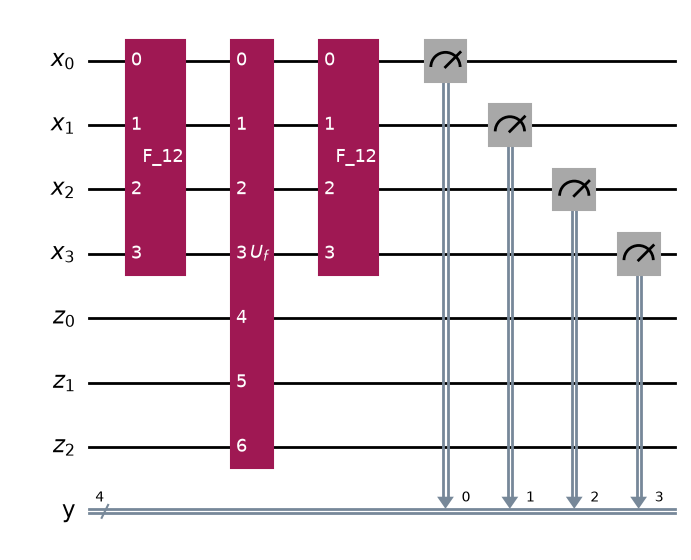

In [6]:
N = 12
oracle, m = make_period_oracle(N, r=6, labels=[5, 1, 7, 0, 6, 3])
sampler = StatevectorSampler(seed=np.random.default_rng(2026))

display(cyclic_sampling_circuit(oracle, N, m).draw("mpl", fold=-1))

Measured integer frequencies: {0: 1, 2: 5, 4: 6, 6: 6, 8: 3, 10: 3}


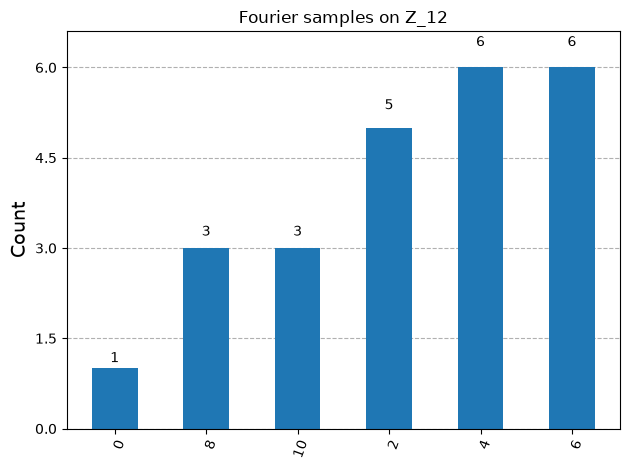

In [7]:
frequencies = sample_frequencies(oracle, N, m, shots=24, sampler=sampler)
counts = Counter(frequencies)
print("Measured integer frequencies:", dict(sorted(counts.items())))
display(plot_histogram(
    {str(y): counts[y] for y in sorted(counts)},
    title="Fourier samples on Z_12",
    sort="value",
))

<a id="classical"></a>
## 3. Classical section

### Combine the frequency constraints with a gcd

Let $d=N/r$. Every sample has the form $y_i=dj_i$ for some
$j_i\in\{0,\ldots,r-1\}$. Compute

$$
g=\gcd(N,y_1,\ldots,y_t).
$$

Factoring out $d$ gives

$$
g=d\,\gcd(r,j_1,\ldots,j_t),
\qquad
\widehat r=\frac Ng
=\frac{r}{\gcd(r,j_1,\ldots,j_t)}.
$$

Thus $\widehat r$ always divides the true period. It equals $r$ exactly when
$\gcd(r,j_1,\ldots,j_t)=1$. The algorithm never needs the unknown $j_i$.
It computes the gcd directly from $N$ and the measured integers.

The gcd also generates the subgroup spanned by the sampled frequencies.
Its annihilator is the candidate hidden subgroup
$\langle N/g\rangle$. As more frequencies are collected, $g$ can decrease
and the candidate period can increase.

For example, in $\mathbb{Z}_{60}$ with true period $12$, the frequencies
$10$ and $15$ are both possible. Individually they give candidate periods
$6$ and $4$. Together they give $60/\gcd(60,10,15)=12$.
Neither frequency alone needs to reveal the full period.

Unlike approximate integer period finding, these samples are exact
multiples of $N/r$. Continued fractions are unnecessary here.

In [8]:
def update_frequency_gcd(N, current_gcd, frequencies):
    '''Update gcd(N, all observed frequencies) without storing old samples.'''
    input_width(N)
    if (not isinstance(current_gcd, int) or current_gcd < 1
            or N % current_gcd):
        raise ValueError("The running gcd must be a positive divisor of N.")
    g = current_gcd
    for y in frequencies:
        if not isinstance(y, int) or not 0 <= y < N:
            raise ValueError("Every frequency must be an integer in [0, N).")
        g = gcd(g, y)
    return g


def period_candidate(N, frequencies):
    g = update_frequency_gcd(N, N, frequencies)
    return N // g, g

In [9]:
candidate, g = period_candidate(N, frequencies)
print("gcd(N, measured frequencies):", g)
print("Candidate period N/g:", candidate)

for partial in ([10], [15], [10, 15]):
    recovered, _ = period_candidate(60, partial)
    print(f"N=60, frequencies={partial}: candidate period={recovered}")

gcd(N, measured frequencies): 2
Candidate period N/g: 6
N=60, frequencies=[10]: candidate period=6
N=60, frequencies=[15]: candidate period=4
N=60, frequencies=[10, 15]: candidate period=12


### Verify the candidate period

Under the oracle promise,

$$
f(\widehat r\bmod N)=f(0)
\quad\Longleftrightarrow\quad r\mid\widehat r.
$$

The frequency calculation already guarantees $\widehat r\mid r$.
Consequently, passing this single membership test proves $\widehat r=r$.
This second fact is essential. An arbitrary period test by itself only
confirms a multiple of the least period.

If the test fails, collect more samples and update the running gcd.
If $\widehat r=N$, then $\widehat r\mid r$ and $r\mid N$ already force
$r=N$, so no verification query is needed.

The test compares two ordinary function values. The implementation obtains
them by querying the oracle on computational-basis inputs. Under ideal
simulation, each such evaluation is deterministic.

In [10]:
def certify_period(N, g, evaluate_f):
    '''Return the certified period, or None if more samples are needed.'''
    update_frequency_gcd(N, g, [])
    candidate = N // g
    if candidate == N:
        return candidate
    if evaluate_f(candidate) == evaluate_f(0):
        return candidate
    return None


def recover_cyclic_period(oracle, N, m, *, batch_size=8, max_batches=6, seed=2026):
    '''Sample and certify the least period without knowing r.'''
    check_oracle_size(oracle, N, m)
    if (not isinstance(batch_size, int) or batch_size < 1
            or not isinstance(max_batches, int) or max_batches < 1):
        raise ValueError("Batch size and maximum batches must be positive.")

    sampler = StatevectorSampler(seed=np.random.default_rng(seed))
    function_queries = 0

    @lru_cache(maxsize=None)
    def evaluate_f(x):
        nonlocal function_queries
        function_queries += 1
        return evaluate_oracle(oracle, N, m, x, sampler)

    g = N
    sample_count = 0
    for batch in range(1, max_batches + 1):
        outcomes = sample_frequencies(oracle, N, m, batch_size, sampler)
        sample_count += len(outcomes)
        g = update_frequency_gcd(N, g, outcomes)
        period = certify_period(N, g, evaluate_f)
        if period is not None:
            return {
                "period": period,
                "subgroup_size": N // period,
                "frequency_gcd": g,
                "sample_count": sample_count,
                "verification_queries": function_queries,
                "batches": batch,
            }
    raise RuntimeError(
        f"Could not certify the period within {sample_count} samples. "
        "Increase max_batches for another bounded attempt."
    )

### Run the complete algorithm

Only the oracle, group size, and output-register size are supplied to the
solver. The period used to construct the oracle is not an input to recovery.
The returned period $r$ represents the subgroup
$\{0,r,2r,\ldots,N-r\}$.

In [11]:
result = recover_cyclic_period(oracle, N, m)
for key, value in result.items():
    print(f"{key}: {value}")
assert result["period"] == 6
assert result["subgroup_size"] * result["period"] == N
print("Recovered hidden subgroup:", list(range(0, N, result["period"])))

period: 6
subgroup_size: 2
frequency_gcd: 2
sample_count: 8
verification_queries: 2
batches: 1
Recovered hidden subgroup: [0, 6]


### Insufficient samples and limiting cases

A zero frequency leaves the running gcd equal to $N$ and gives the candidate
$1$. That candidate is correct for a constant function, but it must be
rejected for the nonconstant demonstration oracle.

The following cell then checks a constant function, an injective function,
a non-power-of-two group, and a power-of-two group. The same recovery
procedure handles each case.

In [12]:
check_sampler = StatevectorSampler(seed=np.random.default_rng(17))
candidate, g_zero = period_candidate(N, [0])
checked = certify_period(
    N, g_zero, lambda x: evaluate_oracle(oracle, N, m, x, check_sampler)
)
assert candidate == 1 and checked is None
print("The zero-only sample set was rejected. More samples are needed.")

cases = [
    ("Constant", 8, 1),
    ("Injective", 8, 8),
    ("Non-power-of-two group", 15, 5),
    ("Power-of-two group", 16, 4),
]
for label, group_size, expected_period in cases:
    test_oracle, output_width = make_period_oracle(group_size, expected_period)
    recovered = recover_cyclic_period(test_oracle, group_size, output_width, seed=41)
    assert recovered["period"] == expected_period
    print(f"{label}: N={group_size}, recovered period={recovered['period']}")

The zero-only sample set was rejected. More samples are needed.
Constant: N=8, recovered period=1
Injective: N=8, recovered period=8


Non-power-of-two group: N=15, recovered period=5


Power-of-two group: N=16, recovered period=4


<a id="cost"></a>
## 4. Success probability and computational cost

After $t\geq1$ independent samples, recovery fails precisely when
$\gcd(r,j_1,\ldots,j_t)>1$. Then some prime $p\mid r$ divides every $j_i$.
Each $j_i$ is uniform modulo $r$, so this event has probability $p^{-t}$.
A union bound gives

$$
\Pr(\widehat r\ne r)
\leq\sum_{p\mid r}p^{-t}
\leq\omega(r)2^{-t}
\leq n2^{-t},
$$

where $\omega(r)$ is the number of distinct prime divisors of $r$ and
$n=\lceil\log_2N\rceil$. The last inequality follows from
$2^{\omega(r)}\leq r\leq N$.
For $r=1$, the failure probability is zero.

Thus $t\geq\lceil\log_2(n/\delta)\rceil$ suffices for failure probability at
most $\delta$, with $0<\delta<1$. This bound does not require factoring $r$
or $N$. Under the promise and ideal sampling, a returned answer is correct.
If certification has not succeeded when the sample limit is reached, the
code reports failure instead.

Let $C_F(N)$ be the elementary-gate cost of the Fourier transform used, and
let $C_f$ be the cost of the oracle. For $t$ samples and $q$ ordinary
verification evaluations, a sufficient gate and measurement count is

$$
O\!\left(t(2C_F(N)+C_f+n+m)+q(C_f+n+m)\right).
$$

For $N=2^n$, the usual exact QFT circuit uses $O(n^2)$ controlled-phase and
Hadamard gates in a model allowing the required rotation angles. Its initial
uniform state costs only $n$ Hadamard gates.
For other $N$, this notebook builds a dense matrix. Its $O(N^2)$ storage and
generic unitary synthesis do not establish a polynomial gate bound in $n$.
The mathematical sampling argument is independent of that implementation
choice.

The classical routine processes each frequency once. Euclid's algorithm uses
$O(n)$ integer remainder operations per gcd on integers with $O(n)$ bits.
Charging the conservative $O(n^2)$ schoolbook bound per remainder gives a
sufficient upper bound of $O(tn^3)$ bit operations for all gcd updates.
The running gcd uses $O(n)$ bits, and retaining a batch of $b$ samples uses
$O(bn)$ bits. Output comparisons cost $O(qm)$ bit operations.
Caching verification values uses $O(q(n+m))$ bits.
Across $B$ batches, at most $B+1$ distinct ordinary evaluations are made.

The statevector simulation uses $O(2^{n+m})$ complex amplitudes, in addition
to any dense Fourier matrix. The explicit oracle builder is also intended
for small examples. Keep these resource costs separate from those of a
structured quantum implementation.

Known finite cyclic groups do not automatically yield an exponential quantum
query advantage. For example, if a factorization of $N$ is supplied,
classical membership tests can reduce an initial period $N$ by its prime
factors until the least period is found.

All certification arguments assume the stated oracle promise and exact
Fourier sampling. Hardware noise or an approximate transform requires a
separate error analysis.

## References

- Andrew M. Childs and Wim van Dam,
  [Quantum algorithms for algebraic problems](https://arxiv.org/abs/0812.0380),
  Sections IV.1 and IV.3 for finite cyclic period finding and its HSP formulation.
- IBM Quantum,
  [QFTGate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.QFTGate),
  [UnitaryGate](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.UnitaryGate),
  and [StatevectorSampler](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorSampler).
- IBM Quantum,
  [Bit ordering](https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering).

Return to [Finite Abelian Hidden Subgroups Problems](../README.md).